# 第 10 章　資料降維：反向淘汰法、卡方檢定法、主成分分析法（PCA）

這是「醫學生的機器學習入門」第 10 章的配套 notebook。

- 在 Google Colab 開啟：選單「執行階段 → 全部執行」即可，不需要額外安裝套件（本章用到的 scikit-learn、statsmodels 都是 Colab 內建）。
- 章節講解請看網站第 10 章；這裡只放可以直接跑的程式碼與簡短說明。
- 圖上的文字用英文，是因為 Colab 預設沒有中文字型。

本章資料集：sklearn 內建 diabetes（反向淘汰）、UCI Cleveland Heart Disease（卡方檢定法，需網路）、sklearn 內建 WDBC 乳癌資料（PCA）。**所有醫學資料僅供學習，不構成臨床建議。**

## 0. 載入套件、確認版本

先匯入本章會用到的套件，並印出版本。本 notebook 在 scikit-learn 1.6（Colab）與 1.9 都測試過。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import statsmodels
import statsmodels.api as sm

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("statsmodels", statsmodels.__version__)

numpy 2.1.3
pandas 2.2.3
scikit-learn 1.6.1
statsmodels 0.15.0


## 1. 反向淘汰法（backward elimination）：用 p 值一步步刪變數

資料：sklearn 內建的 diabetes 資料集，442 位糖尿病人、10 個基線特徵（年齡、性別、BMI、血壓、6 項血清指標 s1–s6），目標是一年後的疾病進展分數（連續值）。特徵已被 sklearn 事先置中與縮放，所以係數大小不好直接解讀，這裡只看 p 值。

In [2]:
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True, as_frame=True)
print(X.shape)
X.head()

(442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


下面這個函式就是教科書版的反向淘汰：先放全部變數做普通最小平方（OLS）迴歸，找出 p 值最大的變數；若它大於 0.05 就刪掉、重新配適，直到剩下的變數 p 值都 ≤ 0.05。

In [3]:
def backward_eliminate(X, y, alpha=0.05, verbose=True):
    cols = list(X.columns)
    while cols:
        model = sm.OLS(y, sm.add_constant(X[cols])).fit()
        pvals = model.pvalues.drop("const")
        worst = pvals.idxmax()
        if pvals[worst] <= alpha:
            break
        if verbose:
            print(f"drop {worst:>4s}  p = {pvals[worst]:.3f}")
        cols.remove(worst)
    return model, cols

model, kept = backward_eliminate(X, y)
print("kept:", kept)
print(f"R2 = {model.rsquared:.3f}, adjusted R2 = {model.rsquared_adj:.3f}")

drop  age  p = 0.867
drop   s3  p = 0.639
drop   s6  p = 0.304
drop   s4  p = 0.262
kept: ['sex', 'bmi', 'bp', 's1', 's2', 's5']
R2 = 0.515, adjusted R2 = 0.508


依序刪掉 age、s3、s6、s4，剩下 6 個變數。接著看最終模型的 p 值與 95% 信賴區間——**要記得這些數字是在「挑過變數之後」才算的，會比實際情況樂觀**（見下一節）。

In [4]:
summary = pd.DataFrame({
    "p": model.pvalues.drop("const").round(4),
    "CI_low": model.conf_int()[0].drop("const").round(1),
    "CI_high": model.conf_int()[1].drop("const").round(1),
})
summary

,p,CI_low,CI_high
sex,0.0002,-344.2,-108.9
bmi,0.0000,400.9,658.9
bp,0.0000,204.0,450.4
s1,0.0000,-1073.3,-442.6
s2,0.0003,250.2,827.0
s5,0.0000,646.6,961.8


## 2. 反向淘汰的問題①：純雜訊也能「挑出顯著變數」

我們造一份**完全沒有關係**的資料：100 個人、20 個隨機特徵、結果也是隨機數。理論上沒有任何特徵真的有用。看看反向淘汰會留下什麼。

In [5]:
rng = np.random.default_rng(42)
Z = pd.DataFrame(rng.normal(size=(100, 20)), columns=[f"z{i}" for i in range(20)])
y_noise = pd.Series(rng.normal(size=100))

noise_model, noise_kept = backward_eliminate(Z, y_noise, verbose=False)
print("kept:", noise_kept)
print(noise_model.pvalues.drop("const").round(3))

kept: ['z2', 'z10', 'z17']
z2     0.006
z10    0.027
z17    0.041
dtype: float64


明明全是雜訊，最後卻留下 3 個 p < 0.05 的變數。原因是：我們讓同一份資料「先挑變數、再算 p 值」，挑的過程已經偏向那些碰巧跟結果相關的變數，最後的 p 值就不再代表原本的意義。

## 3. 反向淘汰的問題②：換一份資料，選出的變數就不一樣

用自助重抽（bootstrap）模擬「如果重新收一批病人」：從 442 人中有放回抽 442 人，每次都重跑一次反向淘汰，統計每個變數被留下的比例。

In [6]:
from collections import Counter

rng = np.random.default_rng(42)
n_boot = 200
freq = Counter()
selected_sets = Counter()
for _ in range(n_boot):
    idx = rng.integers(0, len(X), len(X))
    Xb = X.iloc[idx].reset_index(drop=True)
    yb = y.iloc[idx].reset_index(drop=True)
    _, kept_b = backward_eliminate(Xb, yb, verbose=False)
    freq.update(kept_b)
    selected_sets[tuple(sorted(kept_b))] += 1

inclusion = pd.Series({c: freq[c] / n_boot for c in X.columns}).sort_values(ascending=False)
print(inclusion.round(2))
print("number of different final models:", len(selected_sets))
print("most common model:", selected_sets.most_common(1))

bmi    1.00
bp     1.00
s5     1.00
sex    0.98
s1     0.88
s2     0.55
s4     0.32
s6     0.20
s3     0.18
age    0.04
dtype: float64
number of different final models: 23
most common model: [(('bmi', 'bp', 's1', 's2', 's5', 'sex'), 73)]


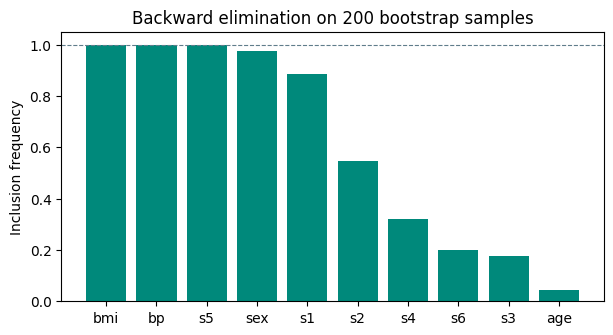

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(inclusion.index, inclusion.values, color="#00897B")
ax.axhline(1.0, color="#607D8B", lw=0.8, ls="--")
ax.set_ylabel("Inclusion frequency")
ax.set_title("Backward elimination on 200 bootstrap samples")
plt.show()

bmi、bp、s5 幾乎每次都被選到，但 s2 大約一半、s4 約三成；200 次重抽出現了二十多種不同的「最終模型」。在原始資料上選出的那一組，只是其中一種可能。

## 4. 以交叉驗證為準的向後選擇：`SequentialFeatureSelector`

scikit-learn 沒有 p 值版的反向淘汰；它提供的 `SequentialFeatureSelector(direction="backward")` 每一步刪掉「刪了之後交叉驗證分數掉最少」的變數。判準是**預測表現**，不是 p 值。

In [8]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

sfs = SequentialFeatureSelector(
    LinearRegression(), n_features_to_select=5, direction="backward", cv=5
)
sfs.fit(X, y)
print("SFS kept:", list(X.columns[sfs.get_support()]))

r2_all = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2").mean()
r2_kept = cross_val_score(LinearRegression(), X[kept], y, cv=5, scoring="r2").mean()
print(f"5-fold CV R2, all 10 features: {r2_all:.3f}")
print(f"5-fold CV R2, 6 kept features: {r2_kept:.3f}")

SFS kept: ['sex', 'bmi', 'bp', 's1', 's5']
5-fold CV R2, all 10 features: 0.482
5-fold CV R2, 6 kept features: 0.491


刪掉 4 個變數後，交叉驗證 R² 幾乎沒變（約 0.48 vs 0.49）：少了變數、模型更精簡，預測力大致持平。**注意**：上面這個比較其實也有一點點「偷看」——`kept` 是用全部資料選出來的。嚴謹的做法要把選變數放進交叉驗證裡面（第 7 節）。

## 5. 卡方檢定法（chi-square）：挑出與結果最相關的類別變數

資料：UCI Cleveland Heart Disease（303 人，1980 年代單一醫學中心，CC BY 4.0）。我們只取 7 個類別型欄位，結果是有沒有冠狀動脈疾病（原始 `num` 0–4，>0 當作有病）。

需要網路；直接讀 UCI 的 CSV。

In [9]:
URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
       "heart-disease/processed.cleveland.data")
names = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach",
         "exang", "oldpeak", "slope", "ca", "thal", "num"]
try:
    heart = pd.read_csv(URL, names=names, na_values="?")
except Exception as e:
    raise RuntimeError(
        "Cannot download Cleveland data from UCI. Check the network, "
        "or download processed.cleveland.data manually and change URL to the local path."
    ) from e

cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
heart = heart.dropna(subset=cat_cols)
Xc = heart[cat_cols].astype(int)
yc = (heart["num"] > 0).astype(int)
print(Xc.shape, "disease rate:", round(yc.mean(), 3))
Xc.head()

(301, 7) disease rate: 0.458


,sex,cp,fbs,restecg,exang,slope,thal
0,1,1,1,2,0,3,6
1,1,4,0,2,1,2,3
2,1,4,0,2,1,2,7
3,1,3,0,0,0,3,3
4,0,2,0,2,0,1,3


`SelectKBest(chi2)` 會替每個特徵算一個「卡方分數」，保留分數最高的 k 個。這個分數是**排序特徵用的篩選分數**，和統計課的列聯表卡方檢定不是同一件事（第 5 節最後會比較）。chi2 **只接受非負值**，這些欄位都是 0、1、2… 的編碼，符合條件。

In [10]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=4).fit(Xc, yc)
chi_table = pd.DataFrame(
    {"chi2": selector.scores_.round(2), "p": selector.pvalues_},
    index=cat_cols,
).sort_values("chi2", ascending=False)
print(chi_table)
print("selected:", list(Xc.columns[selector.get_support()]))

          chi2             p
thal     65.89  4.774151e-16
exang    37.16  1.087056e-09
cp       14.99  1.083368e-04
restecg   9.40  2.166762e-03
slope     8.04  4.577803e-03
sex       7.10  7.696549e-03
fbs       0.06  8.023648e-01
selected: ['cp', 'restecg', 'exang', 'thal']


thal（鉈 201 心肌灌注掃描結果）、exang（運動誘發心絞痛）、cp（胸痛型態）、restecg 分數最高。

**陷阱**：`cp` 是 1–4 的**類別代碼**，sklearn 的 `chi2` 會把它當成「次數」來加總，4 並不代表比 1「多三倍」。比較正確的做法是先 one-hot 編碼，每個類別各自一欄 0/1。

In [11]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
X_onehot = pd.DataFrame(ohe.fit_transform(Xc), columns=ohe.get_feature_names_out())
scores_onehot = pd.Series(chi2(X_onehot, yc)[0], index=X_onehot.columns)
print(scores_onehot.sort_values(ascending=False).round(2).head(8))

thal_7     43.04
cp_4       41.62
exang_1    37.16
thal_3     37.11
slope_1    23.44
cp_3       20.84
slope_2    20.00
exang_0    17.94
dtype: float64


one-hot 之後排名前面的是 thal_7（可逆性灌注缺損）、cp_4（無症狀型胸痛）、exang_1、thal_3（正常），這樣的結果可以直接對回臨床意義。

### sklearn 的 `chi2` 不是列聯表卡方檢定

仔細看上面的輸出：`exang_1` 是 37.16、`exang_0` 是 17.94。同一個變數的兩個 0/1 欄只是互補，如果做的是「exang × 結果」的 2×2 列聯表檢定，兩者應該得到同一個數字。

原因是 sklearn 的 `chi2` 把特徵值當成「次數」：把每一組（有病、沒病）的特徵值加總，和「依各組人數比例分配」的期望值比較。對 0/1 欄來說，它只看「值為 1 的那些人」在兩組怎麼分，完全沒用到值為 0 的人，所以不是完整的列聯表。它的分數適合拿來**排序、篩選特徵**；它附帶的 p 值不宜當成統計推論的依據。

要回答「這個類別變數和結果有沒有關聯」，要用第 2 章的 `scipy.stats.chi2_contingency`，對每個變數建一張「類別 × 結果」列聯表。下面把兩者並排：

In [12]:
from scipy.stats import chi2_contingency

sk_scores, sk_p = chi2(Xc, yc)
rows = []
for i, col in enumerate(cat_cols):
    table = pd.crosstab(Xc[col], yc)  # categories x outcome contingency table
    stat, p, dof, expected = chi2_contingency(table)
    rows.append({"feature": col, "chi2": stat, "dof": dof, "p": p,
                 "min_expected": expected.min(),
                 "sklearn_chi2": sk_scores[i], "sklearn_p": sk_p[i]})

test_table = pd.DataFrame(rows).set_index("feature").sort_values("chi2", ascending=False)
fmt = {"chi2": "{:.2f}".format, "p": "{:.2g}".format, "min_expected": "{:.1f}".format,
       "sklearn_chi2": "{:.2f}".format, "sklearn_p": "{:.2g}".format}
print(test_table.to_string(formatters=fmt))
print()
print("disease rate by fbs:", yc.groupby(Xc["fbs"]).mean().round(3).to_dict())

         chi2  dof       p min_expected sklearn_chi2 sklearn_p
feature                                                       
thal    83.29    2 8.2e-19          8.3        65.89   4.8e-16
cp      80.27    3 2.7e-17         10.5        14.99   0.00011
exang   53.29    1 2.9e-13         44.9        37.16   1.1e-09
slope   44.52    2 2.2e-10          9.6         8.04    0.0046
sex     21.11    1 4.3e-06         44.0         7.10    0.0077
restecg 10.81    2  0.0045          1.8         9.40    0.0022
fbs      0.01    1    0.91         20.2         0.06       0.8

disease rate by fbs: {0: 0.455, 1: 0.477}


兩種數字差很多：cp 的列聯表卡方是 80.27（自由度 3），sklearn 分數只有 14.99；排名也不同。以列聯表檢定來看，thal、cp、exang、slope、sex、restecg 與冠心病的關聯都達統計顯著（p < 0.05），但 restecg 有一格期望次數只有 1.8（低於常用的 5），這個 p 值要保守看待。fbs（空腹血糖 > 120 mg/dL）的 p = 0.91，兩組有病比例 45.5% 與 47.7%，**未達統計顯著**——這只代表「在這份約三百人的資料中沒有偵測到關聯」，不能反推空腹血糖與冠心病無關。

小提醒：2×2 表（自由度 1）時 `chi2_contingency` 預設會做 Yates 連續性校正，所以數字會比未校正版略小。

## 6. 主成分分析（PCA）：把 30 個相關特徵壓成幾個新軸

資料：sklearn 內建 WDBC 乳癌細胞核影像資料，569 個腫瘤、30 個特徵。注意 sklearn 的編碼 **0 = malignant、1 = benign**。

In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = load_breast_cancer()
Xw, yw = data.data, data.target
print(Xw.shape, data.target_names)

Xw_std = StandardScaler().fit_transform(Xw)
pca = PCA().fit(Xw_std)
ratio = pca.explained_variance_ratio_
cum = np.cumsum(ratio)
print("PC1-PC5 explained variance ratio:", ratio[:5].round(3))
print("cumulative, first 5:", cum[:5].round(3))
print("PCs needed for 95%:", int(np.argmax(cum >= 0.95) + 1))

(569, 30) ['malignant' 'benign']
PC1-PC5 explained variance ratio: [0.443 0.19  0.094 0.066 0.055]
cumulative, first 5: [0.443 0.632 0.726 0.792 0.847]
PCs needed for 95%: 10


PC1 一個軸就解釋了 44% 的變異，前 2 個約 63%，要 10 個主成分才到 95%。把它畫成陡坡圖（scree plot）：

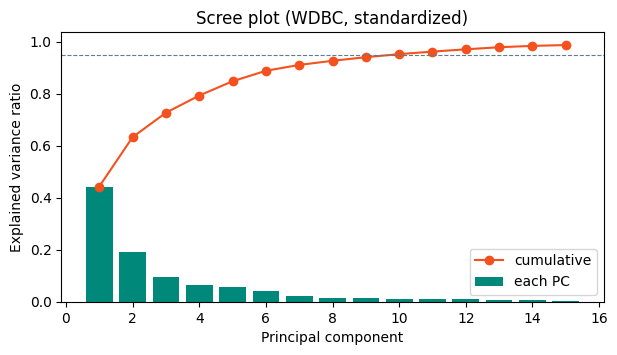

In [14]:
k = np.arange(1, 16)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(k, ratio[:15], color="#00897B", label="each PC")
ax.plot(k, cum[:15], "o-", color="#F4511E", label="cumulative")
ax.axhline(0.95, color="#607D8B", ls="--", lw=0.8)
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("Scree plot (WDBC, standardized)")
ax.legend()
plt.show()

把每個腫瘤投影到前兩個主成分上，再用真正的診斷上色（PCA 本身沒看過診斷）：

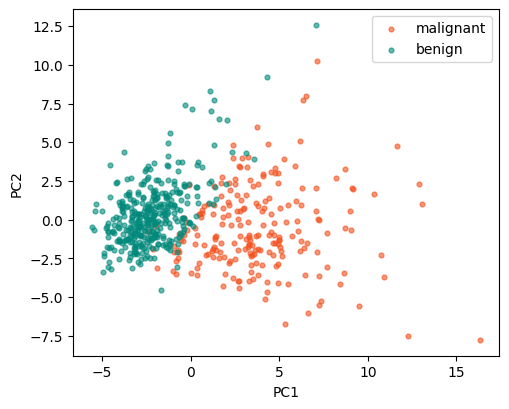

In [15]:
Z2 = PCA(n_components=2).fit_transform(Xw_std)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for label, color in [(0, "#F4511E"), (1, "#00897B")]:
    m = yw == label
    ax.scatter(Z2[m, 0], Z2[m, 1], s=12, alpha=0.6, color=color,
               label=data.target_names[label])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.show()

惡性與良性在 PC1 方向上大致分開。那 PC1 到底是什麼？看它的「載荷（loading）」——每個原始特徵在 PC1 裡的權重：

In [16]:
pca2 = PCA(n_components=2).fit(Xw_std)
loadings = pd.Series(pca2.components_[0], index=data.feature_names)
print(loadings.sort_values(key=abs, ascending=False).head(6).round(3))

mean concave points     0.261
mean concavity          0.258
worst concave points    0.251
mean compactness        0.239
worst perimeter         0.237
worst concavity         0.229
dtype: float64


PC1 權重最大的是 concave points（凹點數）、concavity（凹陷程度）、compactness（緊密度）、perimeter（周長）這些描述「細胞核大小與形狀不規則程度」的特徵，而且正負號一致，可以把 PC1 粗略理解成「細胞核又大又不規則的程度」（正負號本身沒有意義，換個方向也是同一個軸）。

**如果不標準化會怎樣？**

In [17]:
raw_ratio = PCA().fit(Xw).explained_variance_ratio_
print("without scaling, PC1 explains:", raw_ratio[0].round(3))
print("feature variances (top 3):")
print(pd.Series(Xw.var(axis=0), index=data.feature_names).sort_values(ascending=False).head(3).round(0))

without scaling, PC1 explains: 0.982
feature variances (top 3):
worst area    323598.0
mean area     123626.0
area error      2066.0
dtype: float64


不標準化時 PC1 看似解釋了 98% 的變異——但那只是因為 worst area、mean area 的數值（幾百到幾千）遠大於其他特徵，PC1 幾乎就等於「面積」。PCA 會置中但**不會縮放**，所以一定要先標準化。

## 7. 把降維放進 Pipeline：選幾個主成分比較好？

用 `Pipeline` 串起「標準化 → PCA → 邏輯迴歸」，每一折交叉驗證都只在訓練折上配適標準化與 PCA。

In [18]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for n in [1, 2, 3, 5, 10, 30]:
    pipe = make_pipeline(StandardScaler(), PCA(n_components=n),
                         LogisticRegression(max_iter=1000))
    acc = cross_val_score(pipe, Xw, yw, cv=cv).mean()
    print(f"{n:2d} PCs: CV accuracy = {acc:.3f}")

 1 PCs: CV accuracy = 0.910
 2 PCs: CV accuracy = 0.947
 3 PCs: CV accuracy = 0.942
 5 PCs: CV accuracy = 0.963
10 PCs: CV accuracy = 0.977


30 PCs: CV accuracy = 0.974


2 個主成分就有約 0.95 的準確率，10 個主成分與全部 30 個特徵差不多（約 0.97–0.98）。要記得：WDBC 是單一來源、樣本數 569 的資料，準確率高不代表能直接用在別家醫院。

## 8. 資料洩漏（data leakage）示範：先選特徵、再交叉驗證

最後示範一個常見錯誤。造 100 位「病人」、5,000 個**純雜訊**特徵、隨機的 0/1 結果。正確的準確率應該接近 0.5（猜硬幣）。

In [19]:
from sklearn.feature_selection import f_classif

rng = np.random.default_rng(42)
X_noise = rng.normal(size=(100, 5000))
y_coin = rng.integers(0, 2, size=100)

# Wrong: select features on ALL data, then cross-validate
X_selected = SelectKBest(f_classif, k=20).fit_transform(X_noise, y_coin)
acc_wrong = cross_val_score(LogisticRegression(max_iter=1000), X_selected, y_coin, cv=cv).mean()

# Right: feature selection inside the pipeline
pipe_right = make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=1000))
acc_right = cross_val_score(pipe_right, X_noise, y_coin, cv=cv).mean()

print(f"selection outside CV: {acc_wrong:.2f}")
print(f"selection inside pipeline: {acc_right:.2f}")

selection outside CV: 0.88
selection inside pipeline: 0.53


在全部資料上先挑特徵，準確率被灌到約 0.88；放進 Pipeline 後回到約 0.5，這才是真相。

## 動手試試

1. 把第 1 節 `backward_eliminate` 的 `alpha` 改成 0.10 或 0.01，最後留下的變數有什麼不同？
2. 把第 2 節的雜訊特徵從 20 個改成 50 個，看看反向淘汰會「找到」幾個顯著變數。
3. 在第 7 節把 `LogisticRegression` 換成第 6 章的 `SVC()`，比較 2 個主成分與 30 個特徵的準確率。